# 🏠 New York Housing Dataset Analysis
**LAB University of Applied Sciences — NumPy/Pandas Exercise**

This notebook filters CSV data, computes min/max, creates price bins, and visualizes price per sqft by longitude and latitude.

## 1. Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded!')

Libraries loaded!


## 2. Load & Filter CSV Data

In [9]:
df = pd.read_csv('NY-House-Dataset.csv')
print(f'Raw records: {len(df)}')
df.head()

Raw records: 4801


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [10]:
df = df.dropna(subset=['LATITUDE', 'LONGITUDE', 'PRICE', 'PROPERTYSQFT'])
df = df[df['PROPERTYSQFT'] > 0]
df = df[df['PRICE'] > 0]
df = df[df['PROPERTYSQFT'] < 10000]
df = df[df['PRICE'] < 10_000_000]

df['PRICE_PER_SQFT'] = df['PRICE'] / df['PROPERTYSQFT']
df = df[df['PRICE_PER_SQFT'] < 30000]

print(f'Records after filtering: {len(df)}')

Records after filtering: 4620


## 3. Min & Max

In [11]:
min_price = df['PRICE'].min()
max_price = df['PRICE'].max()
min_sqft  = df['PRICE_PER_SQFT'].min()
max_sqft  = df['PRICE_PER_SQFT'].max()

print(f'Price  — Min: ${min_price:,.2f}  |  Max: ${max_price:,.2f}')
print(f'$/sqft — Min: ${min_sqft:,.2f}  |  Max: ${max_sqft:,.2f}')

Price  — Min: $2,494.00  |  Max: $9,999,000.00
$/sqft — Min: $1.14  |  Max: $4,685.79


## 4. Price Bins (5 equal-width bins on $/sqft)

In [12]:
bins = np.linspace(min_sqft, max_sqft, 6)
labels = [f'Bin {i}: ${bins[i]:,.2f} - ${bins[i+1]:,.2f}' for i in range(5)]
df['BIN'] = pd.cut(df['PRICE_PER_SQFT'], bins=bins, labels=range(5), include_lowest=True)

for lbl in labels:
    print(lbl)

Bin 0: $1.14 - $938.07
Bin 1: $938.07 - $1,875.00
Bin 2: $1,875.00 - $2,811.93
Bin 3: $2,811.93 - $3,748.86
Bin 4: $3,748.86 - $4,685.79


## 5. Charts — Longitude & Latitude vs Price per Sqft

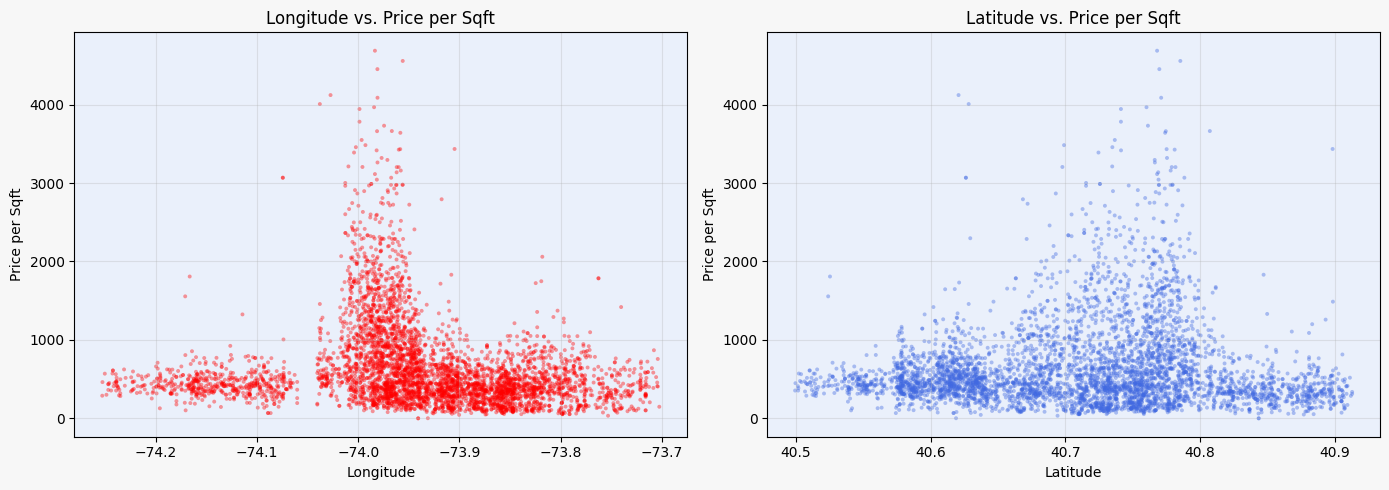

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f7f7f7')

ax1.scatter(df['LONGITUDE'], df['PRICE_PER_SQFT'], c='red', alpha=0.4, s=8, edgecolors='none')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Price per Sqft')
ax1.set_title('Longitude vs. Price per Sqft')
ax1.set_facecolor('#eaf0fb')
ax1.grid(True, alpha=0.3)

ax2.scatter(df['LATITUDE'], df['PRICE_PER_SQFT'], c='royalblue', alpha=0.4, s=8, edgecolors='none')
ax2.set_xlabel('Latitude')
ax2.set_ylabel('Price per Sqft')
ax2.set_title('Latitude vs. Price per Sqft')
ax2.set_facecolor('#eaf0fb')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('charts_lon_lat.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Map — Price per Sqft by Location

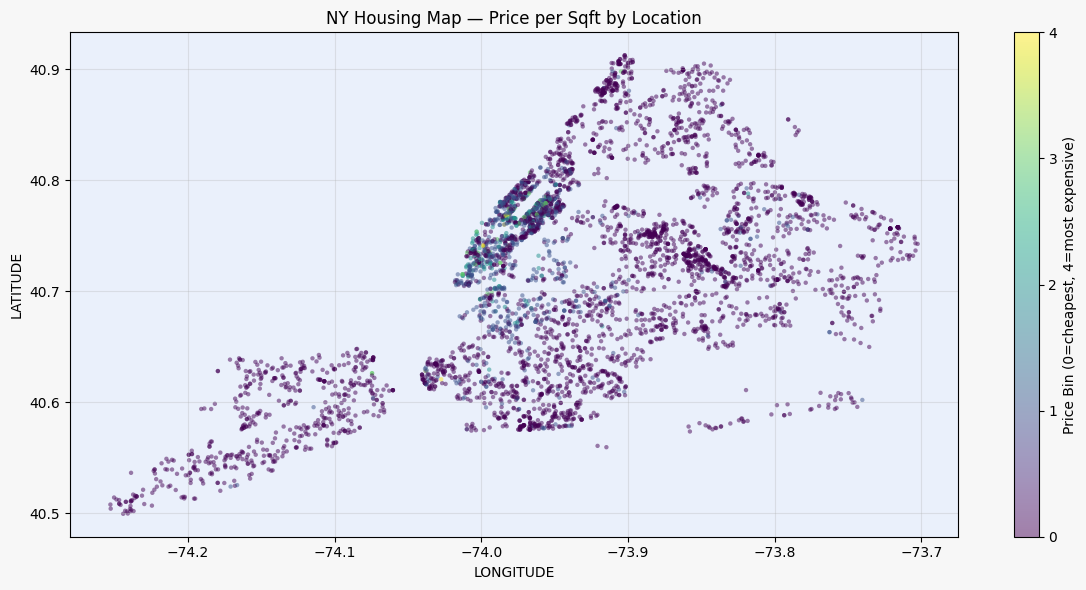

In [14]:
valid = df.dropna(subset=['BIN'])

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f7f7f7')

scatter = ax.scatter(valid['LONGITUDE'], valid['LATITUDE'],
                     c=valid['BIN'].astype(float),
                     cmap='viridis', alpha=0.5, s=10,
                     vmin=0, vmax=4, edgecolors='none')
cbar = plt.colorbar(scatter, ax=ax, ticks=[0,1,2,3,4])
cbar.set_label('Price Bin (0=cheapest, 4=most expensive)')
ax.set_xlabel('LONGITUDE')
ax.set_ylabel('LATITUDE')
ax.set_title('NY Housing Map — Price per Sqft by Location')
ax.set_facecolor('#eaf0fb')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('map_price_bins.png', dpi=150, bbox_inches='tight')
plt.show()